In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
import glob
import tqdm

In [2]:
paths = glob.glob("/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif-ON0090_m6A/*.pkl")

data_list = []
for path in tqdm.tqdm(paths):
    data = pd.read_pickle(path)["pred"].values
    data_list.append(data)

data = np.concatenate(data_list)

print(data)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2808/2808 [05:45<00:00,  8.12it/s]


[0.00236216 0.0012985  0.00052604 ... 0.00250542 0.00067172 0.00237819]


In [3]:
pos_data = data[data>=0.5]
neg_data = data[data<0.5]

print(len(pos_data), len(neg_data))

88362197 2716301004


In [5]:
pos_10th = np.percentile(pos_data, 10)
neg_90th = np.percentile(neg_data, 90)
print(pos_10th, neg_90th)

0.5495672225952148 0.04242560639977455


In [6]:
pos_5th = np.percentile(pos_data, 5)
neg_95th = np.percentile(neg_data, 95)
print(pos_5th, neg_95th)

0.5495672225952148 0.04242560639977455


In [7]:

print(pos_5th, neg_95th)

0.5242885231971741 0.12881721556186676


In [8]:
pos_bound = np.percentile(pos_data, 1*len(data)/len(pos_data))
neg_bound = np.percentile(neg_data, 100-1*len(data)/len(neg_data))
print(pos_bound, neg_bound)

0.6692989468574524 0.3698103427886963


In [9]:
pos_bound = np.percentile(pos_data, 0.5*len(data)/len(pos_data))
neg_bound = np.percentile(neg_data, 100-0.5*len(data)/len(neg_data))
print(pos_bound, neg_bound)

0.5803894400596619 0.4297464191913605


In [ ]:
from sklearn.mixture import GaussianMixture

In [17]:
pos_data_sample = np.random.choice(pos_data, 10000)
gmm = GaussianMixture(n_components=1)
gmm.fit(pos_data_sample.reshape(-1,1))
print(gmm.means_, gmm.covariances_)

[[0.78003863]] [[[0.02657163]]]


In [19]:
neg_data_sample = np.random.choice(neg_data, 10000)
gmm = GaussianMixture(n_components=1)
gmm.fit(neg_data_sample.reshape(-1,1))
print(gmm.means_, gmm.covariances_)

[[0.01878868]] [[[0.00381177]]]


In [45]:
data_sample = np.random.choice(data, 100000)
gmm = GaussianMixture(n_components=2, covariance_type="full", tol=1e-6)
gmm.fit(data_sample.reshape(-1,1))
print(gmm.means_, gmm.covariances_)

[[0.0010673 ]
 [0.18872642]] [[[2.83291669e-06]]

 [[7.11322386e-02]]]


/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


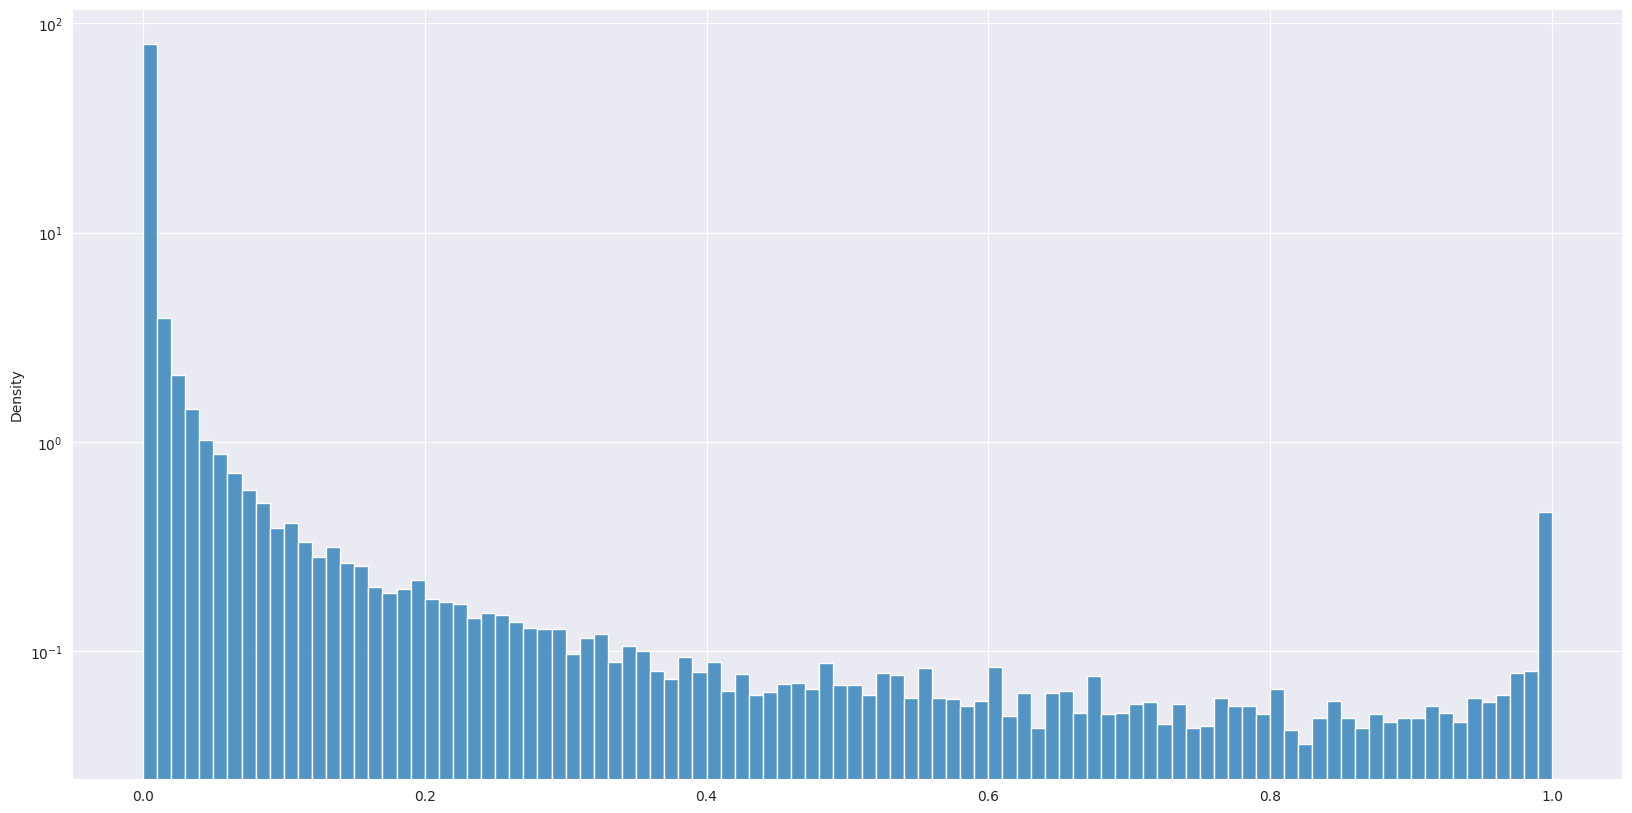

In [49]:
## Plot log histogram of data
plt.figure(figsize=(20,10))
sns.histplot(data_sample, bins=100, stat="density")
plt.yscale("log")
plt.show()

In [47]:
print(np.log10(0.8))
print(np.log10(0.4))

-0.09691001300805639
-0.3979400086720376


In [38]:
data_sample = np.random.choice(data, 100000)
data_sample = np.log10(data_sample)
gmm = GaussianMixture(n_components=3, covariance_type="diag", tol=1e-6)
gmm.fit(data_sample.reshape(-1,1))
print(gmm.means_)

[[-3.41257008]
 [-0.71550586]
 [-2.44851092]]


/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/sklearn/mixture/_base.py:268: ConvergenceWarning: Initialization 1 did not converge. Try different init parameters, or increase max_iter, tol or check for degenerate data.
  warnings.warn(


In [39]:
print(gmm.covariances_)

[[0.12687035]
 [0.23330806]
 [0.42503952]]


/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


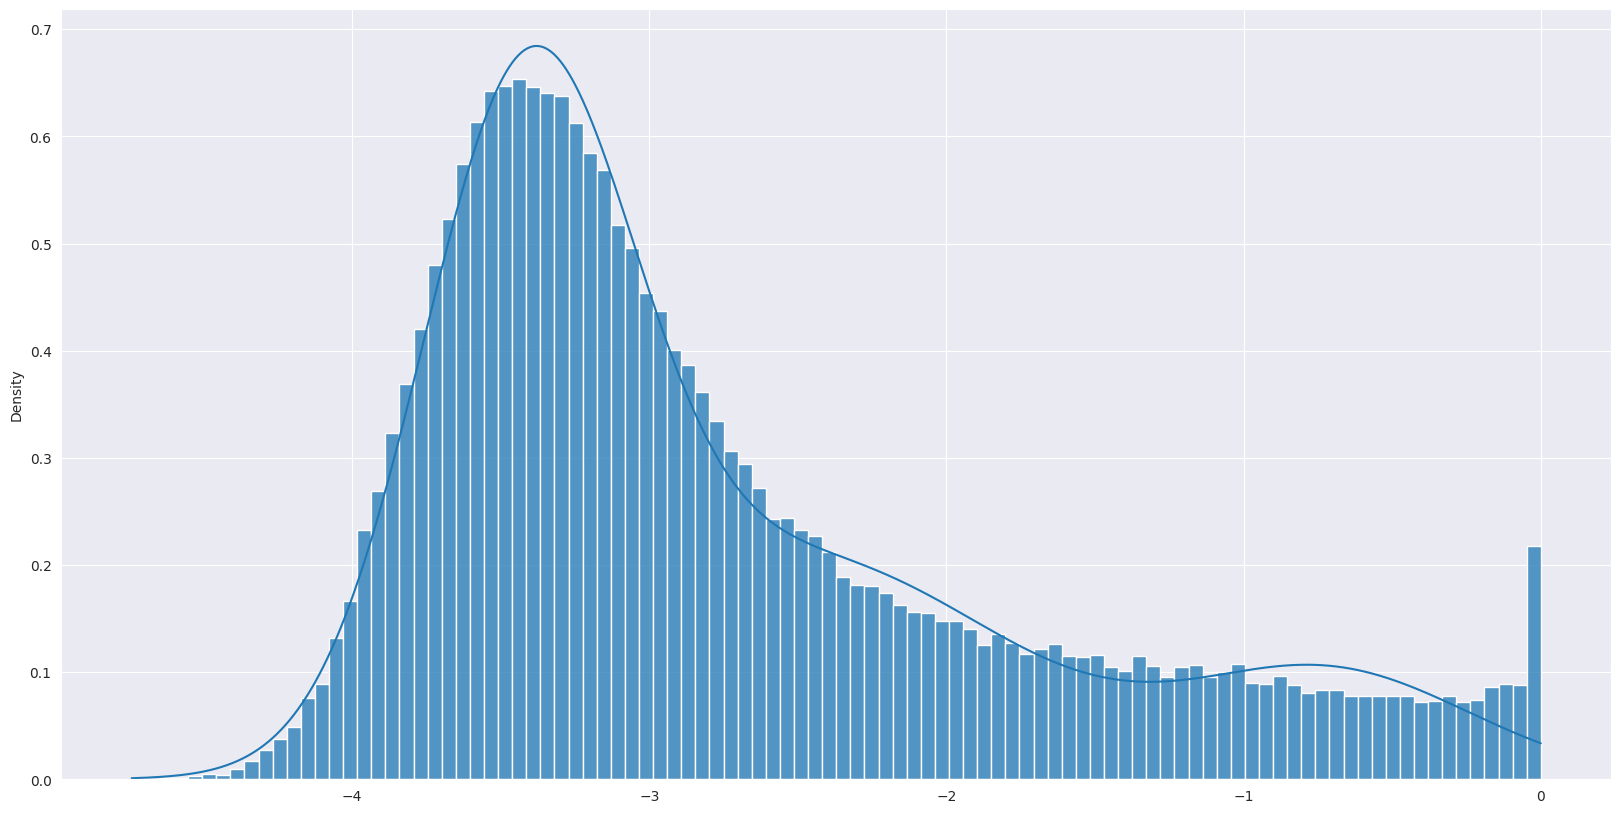

In [40]:
## Plot histogram with GMM
plt.figure(figsize=(20,10))
sns.histplot(data_sample, bins=100, stat="density")
x = np.linspace(data_sample.min(), data_sample.max(), 1000)
y = np.exp(gmm.score_samples(x.reshape(-1,1)))
plt.plot(x, y)
plt.show()

In [57]:
path = "/extdata4/baeklab/Hyeonseo/m6A/dataset/ver101424_pseU/score-0.0/val/pos/000027708.npz"
with np.load(path) as npz: data = pd.DataFrame({key:list(npz[key]) for key in npz.keys()})
print(data)    

                                        segment_len_arr  \
0     [4, 4, 6, 8, 6, 4, 6, 2, 4, 2, 2, 2, 2, 4, 2, ...   
1     [4, 4, 4, 8, 4, 4, 4, 4, 2, 6, 4, 4, 6, 4, 10,...   
2     [4, 6, 4, 2, 2, 2, 22, 4, 6, 6, 4, 6, 4, 4, 6,...   
3     [4, 2, 4, 4, 10, 4, 6, 4, 8, 2, 2, 4, 2, 6, 4,...   
4     [2, 2, 4, 2, 6, 4, 2, 4, 2, 6, 4, 10, 4, 4, 4,...   
...                                                 ...   
3995  [2, 4, 6, 20, 4, 8, 4, 6, 4, 4, 4, 4, 6, 2, 6,...   
3996  [4, 2, 2, 4, 2, 2, 4, 2, 2, 4, 2, 2, 4, 4, 4, ...   
3997  [6, 4, 4, 6, 4, 2, 4, 4, 4, 4, 10, 4, 8, 4, 8,...   
3998  [2, 2, 4, 2, 2, 4, 4, 4, 6, 8, 6, 4, 4, 4, 8, ...   
3999  [6, 6, 6, 6, 6, 4, 4, 2, 4, 4, 4, 8, 58, 10, 2...   

                                           signal_token  \
0     [-0.40867165, -0.2431218, -0.19582184, -0.6767...   
1     [-0.11588879, 0.18468732, -0.08249144, 0.15963...   
2     [0.4842615, 0.49233252, 0.43583536, 0.12106538...   
3     [2.1572344, 2.415781, 1.946567, 1.7933544, 1.6...

In [64]:
file_path = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif-ON0090_m6A{postfix}/pileup.npz"
postfix_list = ["50_50", "20_80", "40_60", "5th", "10th", "1percent", "2percent"]

data_dict = {}

for postfix in postfix_list:
    with np.load(file_path.format(postfix=postfix), allow_pickle=True) as npz: 
        data = pd.DataFrame({key: npz[key] for key in npz.keys()})
    data_dict[postfix] = data

In [65]:
label_df = pd.read_csv("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/label/Baeklab.070.GP3.depth5_None.twm6astrict.tsv", sep="\t")
label_df = label_df[["id", "depth", "label", "m6A_level", "5mer", "drach"]]
label_df.rename(columns = {"id": "label_id","m6A_level": "dom_label"}, inplace = True)
print(label_df)

                label_id  depth  label  dom_label   5mer  drach
0           NM_000084:34      7      0        0.0  GCAGA  False
1           NM_000084:36      7      0        0.0  AGAGA  False
2           NM_000084:38      7      0        0.0  AGAAT  False
3           NM_000084:39      7      0        0.0  GAATG  False
4           NM_000084:43      7      0        0.0  GCAGC  False
...                  ...    ...    ...        ...    ...    ...
30960573  NR_183446:1338     51     -3        0.0  AGAAG  False
30960574  NR_183446:1339     51     -3        0.0  GAAGC  False
30960575  NR_183446:1347     51     -3        0.0  TCATT  False
30960576  NR_183446:1350     51     -3        0.0  TTAGC  False
30960577  NR_183446:1353     51     -3        0.0  GCAGG  False

[30960578 rows x 6 columns]


In [66]:
for postfix in tqdm.tqdm(postfix_list):
    data = data_dict[postfix]
    data = data.merge(label_df, on="label_id", how="inner")
    data_dict[postfix] = data

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [09:12<00:00, 78.98s/it]


In [67]:
for postfix in tqdm.tqdm(postfix_list):
    data = data_dict[postfix]
    data["pm6a"] =  -(2-data["dom"])*data["logsum_1_p_pos"]/data["count_all"] + ((1-data["dom"])*np.log10(np.clip(1-data["dom"],1e-30,1)) + data["dom"] * np.log10(np.clip(data["dom"],1e-30,1)))*(data["count_pos"]/data["count_all"])
    data["dom_threshold"] = np.log10(0.02)*(data["dom"]) > data["logsum_1_p_pos"]/data["count_all"]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:46<00:00,  6.63s/it]


In [68]:
from scipy import stats


In [82]:
from sklearn import metrics
for postfix in postfix_list:
    data = data_dict[postfix]
    data = data[data["dom_threshold"] & (data["count_dom"]>=20)]
    r2 = metrics.r2_score(data["dom_label"], data["dom"])
    print(postfix, r2)

50_50 0.7762889097570184
20_80 0.7917694913680319
40_60 0.7820080291019191
5th 0.7735869937536815
10th 0.7707588975665413
1percent 0.7810867402310588
2percent 0.7858747888793376


In [73]:
from sklearn.metrics import precision_recall_curve, auc

In [75]:

for postfix in postfix_list:
    data = data_dict[postfix]
    data = data[(data["count_dom"]>=20) & (((data["dom_label"] > 0.1) & (data["label"] == 1)) | (data["label"] == 0))]
    precision, recall, _ = precision_recall_curve(data["label"], data["pm6a"])
    ap = auc(recall, precision)
    print(postfix, ap)

50_50 0.9090248367978846
20_80 0.9129592991075317
40_60 0.9100683922756841
5th 0.9125148900885189
10th 0.9155197380015925
1percent 0.9098474346369181
2percent 0.9107774646190135


In [77]:
 df  = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/label/101424_postprocess_label.pkl")

In [78]:
print(df)

              label_id  count_all  count_dom       dom  m6a_score  label  \
0       NM_000016:2072         45         44  0.022727   0.107359      0   
1       NM_000016:2103         36         36  0.055556   0.264506      0   
2       NM_000016:2112         36         36  0.027778   0.095094      0   
3       NM_000017:1825         93         89  0.123596   0.402387      0   
4       NM_000018:2175         77         77  0.012987   0.071006      0   
...                ...        ...        ...       ...        ...    ...   
776810   NR_184306:731         16         16  0.375000   1.341954     -3   
776811   NR_184306:740         15         13  0.076923   0.507125     -3   
776812   NR_184306:769         16         14  0.785714   1.919012     -3   
776813    NR_184306:77         49         46  0.260870   1.229243     -3   
776814    NR_184306:93         50         46  0.695652   1.919874     -3   

        dom_label   5mer  drach  label_index  
0             0.0  TTATT  False         

In [79]:
print(stats.pearsonr(df["dom_label"], df["dom"])[0]**2)

0.6825223635629151
